FEATURE SELECTION & MODEL SELECTION

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df_prep= pd.read_csv("cisco_firewall_preprocessed_dataset.csv")
df_prep


,model_series,cpu_util_avg,memory_util_avg,port_util_avg,interface_error_rate,connection_rate_cps,syn_flood_events,inspection_drop_rate,fragmented_packet_pct,ssl_decrypt_enabled,...,reboot_count,failover_events,core_file_count,core_file_flag,device_stability_score,severity_encoded,model_sku_A1M,model_sku_A2H,model_sku_A2L,model_sku_A2M
0,260,-1.363345,1.259906,1.289599,0.172967,-0.839855,1.336207,-1.414355,1.353863,1,...,0.362031,0.544331,1.418510,1,-0.764169,0,0,0,0,1
1,220,-0.525063,1.565812,-1.501731,-1.420899,-1.196440,-1.617057,-1.863179,-1.235555,0,...,0.362031,-0.362887,-1.994447,0,2.396785,0,0,0,0,0
2,260,1.443924,1.032255,0.288059,1.026611,-1.179300,-0.864264,-1.635027,-0.553951,0,...,-0.820110,1.451549,-0.287968,1,-0.764169,0,0,1,0,0
3,260,-0.823986,0.612523,-0.166344,1.056458,-1.365597,-0.458914,0.672674,-0.582704,1,...,-0.229040,-1.270106,0.565271,1,-0.764169,0,0,1,0,0
4,220,0.514666,0.299503,0.589448,0.363992,0.686824,1.509929,0.081723,-1.357330,0,...,-0.229040,0.544331,-0.287968,1,-0.764169,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,240,0.703117,0.470242,1.475070,-1.080635,-1.049195,-1.037985,-0.613953,-0.011036,1,...,-1.411180,0.544331,-1.141208,0,0.523024,0,0,0,0,1
76,240,1.229480,-1.073517,1.224685,-0.459803,-0.866279,0.120157,-1.795855,0.775430,1,...,-0.229040,1.451549,-0.287968,1,-0.487178,0,0,0,0,1
77,260,1.261972,-1.514590,0.473529,1.313148,0.820400,0.178064,0.137826,1.106930,1,...,-0.229040,-0.362887,1.418510,1,-0.764169,0,0,0,0,1
78,260,-0.356107,-0.354993,1.011394,-1.355234,1.529637,0.583414,0.081723,0.760208,0,...,0.362031,-0.362887,-1.141208,0,1.207354,0,1,0,0,0


In [2]:
#FEATURES AND TARGET COLUMN

X = df_prep.drop(columns=["core_file_flag"])  # all other columns
y = df_prep["core_file_flag"]

print("Feature columns:", X.columns)
print("Target column: core_file_flag")

Feature columns: Index(['model_series', 'cpu_util_avg', 'memory_util_avg', 'port_util_avg',
       'interface_error_rate', 'connection_rate_cps', 'syn_flood_events',
       'inspection_drop_rate', 'fragmented_packet_pct', 'ssl_decrypt_enabled',
       'image_upgrade_count', 'reboot_count', 'failover_events',
       'core_file_count', 'device_stability_score', 'severity_encoded',
       'model_sku_A1M', 'model_sku_A2H', 'model_sku_A2L', 'model_sku_A2M'],
      dtype='object')
Target column: core_file_flag


In [3]:
#TRAIN and TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("\nTrain shape:", X_train.shape)
print("\nTest shape:", X_test.shape)


Train shape: (64, 20)

Test shape: (16, 20)


In [4]:
# FEATURE IMPORTANCE USING RANDOM FOREST
import warnings
warnings.filterwarnings("ignore")
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Feature importance
feat_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
feat_importances = feat_importances.sort_values(ascending=False)
# 4. FEATURE IMPORTANCE USING RANDOM FOREST
# -----------------------------
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

print("\nTop Features:\n", feat_importances.head(10))


Top Features:
 core_file_count           0.228701
syn_flood_events          0.142561
cpu_util_avg              0.113924
device_stability_score    0.108086
fragmented_packet_pct     0.065722
interface_error_rate      0.064210
port_util_avg             0.062799
inspection_drop_rate      0.052636
connection_rate_cps       0.036133
reboot_count              0.035543
dtype: float64


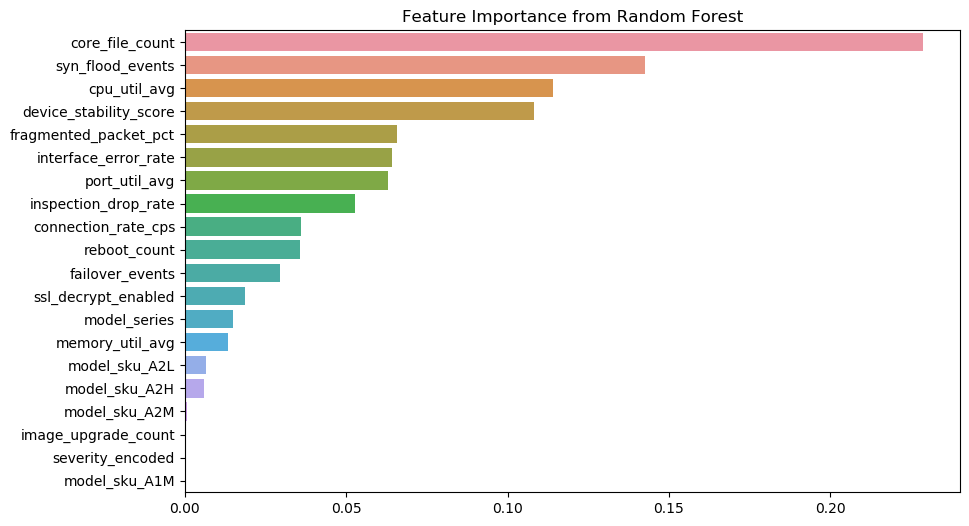

In [5]:
plt.figure(figsize=(10,6))
sns.barplot(x=feat_importances.values, y=feat_importances.index)
plt.title("Feature Importance from Random Forest")
plt.show()

In [6]:
# GRID SEARCH FOR HYPERPARAMETER TUNING (SAFE)
import warnings
warnings.filterwarnings("ignore")

param_grid = {
    "n_estimators": [50, 100],      # smaller grid for small dataset
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 4],
    "min_samples_leaf": [1, 2]
}

# Use StratifiedKFold to handle small dataset
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=1  # avoid worker crash
)

grid_search.fit(X_train, y_train)
print("Grid Search completed.")
print("Best parameters:", grid_search.best_params_)


Grid Search completed.
Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


In [7]:
# FINAL MODEL EVALUATION

best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.75      0.86         4
           1       0.92      1.00      0.96        12

    accuracy                           0.94        16
   macro avg       0.96      0.88      0.91        16
weighted avg       0.94      0.94      0.93        16

Accuracy Score: 0.9375


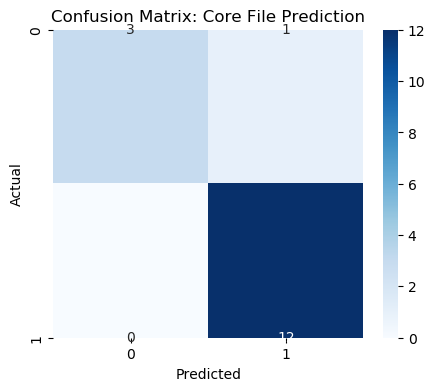

In [8]:
# Confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix: Core File Prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()